# Credit VaR Simulation
Monte Carlo-based estimation of Value at Risk and Expected Shortfall under credit default uncertainty.


In [8]:
import pandas as pd
import joblib
import numpy as np

In [4]:
# Load raw (unencoded, unscaled) test set
X_test_raw = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_beforeenc.csv")
y_test_raw = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_beforeenc.csv")

# Load final encoded + scaled test set
X_test_final = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_final.csv")
y_test_final = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_final.csv")

X_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_train_beforeenc.csv")
y_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_train_beforeenc.csv").squeeze()

xgb_model = joblib.load("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/models/xgb_credit_model_final.pkl")

# Preview shapes to confirm successful loading
print("Raw shapes:", X_test_raw.shape, y_test_raw.shape)
print("Final shapes:", X_test_final.shape, y_test_final.shape)


Raw shapes: (272380, 99) (272380, 1)
Final shapes: (272380, 16) (272380, 1)


In [5]:
y_pred_proba = xgb_model.predict_proba(X_test_final)[:, 1]

In [6]:
# Exposure at default (loan amount)
ead = X_test_raw["funded_amnt"].values

# Assume fixed LGD (adjust for stress if needed)
LGD = 0.65

### Credit Loss Simulations via Monte Carlo (Using Test Set Predictions)

We perform a **Monte Carlo simulation** to estimate the **distribution of potential credit losses** across a portfolio of loans. This approach accounts for uncertainty in borrower behavior using probabilistic modeling.



#### Simulation Setup

- **Predicted PDs** (`y_pred_proba`) are treated as the probability that each borrower defaults.
- **Exposure at Default** (`EAD`) is taken from the test set's `funded_amnt`.
- **Loss Given Default** (`LGD`) is assumed constant at **0.65**, typical for personal lending.



#### Simulation Logic

We simulate **10,000 scenarios** using a **binomial default process** for each loan:

- For each simulation:
  - Every loan is assigned a `1` (default) or `0` (no default), drawn randomly from a Bernoulli distribution with probability equal to its predicted PD.
  - This models whether each borrower defaults in that scenario.

- For each simulated scenario:
  - **Loss on each loan** is:
    $$
    \text{Loss}_i = \text{Default}_{i,s} \times \text{LGD} \times \text{EAD}_i
    $$
  - Total **portfolio loss** is the sum across all loans.

- This results in a **distribution of portfolio-level expected losses** across simulations.

These simulations form the basis for computing **Value at Risk (VaR)** and **Expected Shortfall (ES)**.

In [9]:
# Simulate 10,000 scenarios
n_simulations = 10000
np.random.seed(42)

# Each simulation samples defaults based on predicted PDs
simulated_defaults = np.random.binomial(n=1, p=y_pred_proba, size=(n_simulations, len(y_pred_proba)))
losses = simulated_defaults * (LGD * ead)  # matrix of shape (10000, num_loans)

# Total loss per scenario (portfolio loss distribution)
portfolio_losses = losses.sum(axis=1)

### Value-at-Risk Confidence Level

We define a **confidence level of 99%**, which is standard in Basel III and IV for credit risk capital adequacy.

- **Confidence Level**: 99%
- **Quantile**: 1st percentile of worst-case losses
- VaR answers the question:  
  > "What is the maximum loss I should expect not to exceed 99% of the time?"

This sets the cutoff for both **VaR** and **Expected Shortfall** computations.


In [10]:
confidence_level = 0.99  # 99% VaR

# Value at Risk at 99% (loss that won't be exceeded with 99% confidence)
var_99 = np.percentile(portfolio_losses, 100 * confidence_level)

# Expected Shortfall = avg loss in worst 1%
es_99 = portfolio_losses[portfolio_losses >= var_99].mean()

print(f"Portfolio VaR (99%): ${var_99:,.2f}")
print(f"Expected Shortfall (99%): ${es_99:,.2f}")


Portfolio VaR (99%): $864,343,302.39
Expected Shortfall (99%): $864,983,020.36


### Portfolio Risk Results

#### Portfolio Value-at-Risk (99%):
**\$864,343,302.39**

This means that under normal market conditions, with 99% confidence, **total credit losses should not exceed $864.3 million**.

#### Expected Shortfall (CVaR, 99%):
**\$864,983,020.36**

This indicates that in the **worst 1% of cases**, the **average credit loss** is approximately **$865.0 million** — slightly higher than the VaR, implying **moderate tail risk**.



#### Interpretation:
- A **small gap between VaR and ES** suggests that the **tail of the loss distribution is not extremely fat**, indicating a fairly stable risk structure under current assumptions.
- These risk metrics are useful for:
  - Stress testing
  - Capital requirement estimation
  - Internal risk appetite frameworks


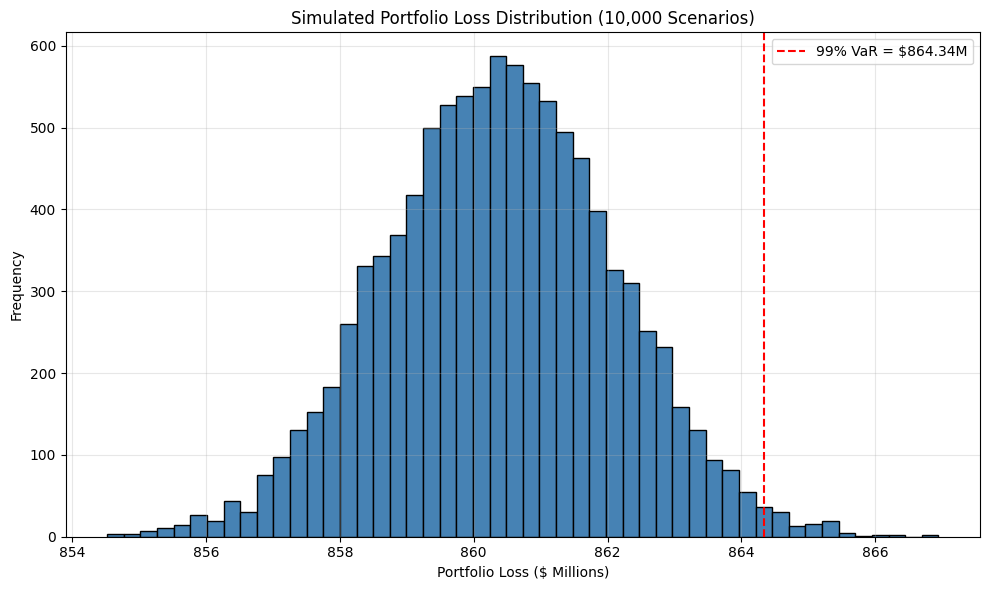

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(portfolio_losses / 1e6, bins=50, color='steelblue', edgecolor='black')
plt.axvline(var_99 / 1e6, color='red', linestyle='--', label=f"99% VaR = ${var_99/1e6:.2f}M")
plt.title("Simulated Portfolio Loss Distribution (10,000 Scenarios)")
plt.xlabel("Portfolio Loss ($ Millions)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This histogram shows the simulated credit portfolio loss distribution under 10,000 scenarios.  
The 99% **Value at Risk (VaR)** is approximately **$864.34M**, meaning there's only a 1% chance the loss will exceed this amount in extreme conditions.

---

In [12]:
grades = sorted(X_test_raw['grade'].unique())  # ['A', 'B', ..., 'G']
grade_var_results = []

n_simulations = 10000
np.random.seed(42)
LGD = 0.65  # or whatever you're using
conf_level = 0.99

for g in grades:
    # Filter PDs and EADs by grade
    mask = X_test_raw['grade'] == g
    pd_grade = y_pred_proba[mask]
    ead_grade = X_test_raw.loc[mask, 'funded_amnt'].values

    # Skip if no loans of this grade
    if len(pd_grade) == 0:
        continue

    # Simulate defaults
    sim_defaults = np.random.binomial(n=1, p=pd_grade, size=(n_simulations, len(pd_grade)))
    losses = sim_defaults * (LGD * ead_grade)
    total_losses = losses.sum(axis=1)

    # VaR and ES
    var = np.percentile(total_losses, conf_level * 100)
    es = total_losses[total_losses >= var].mean()

    grade_var_results.append({
        'grade': g,
        'num_loans': len(pd_grade),
        'VaR_99': var,
        'Expected_Shortfall_99': es,
        'avg_loss': total_losses.mean()
    })

grade_risk_df = pd.DataFrame(grade_var_results)


In [13]:
# Display the full DataFrame
pd.set_option('display.float_format', lambda x: f'${x:,.2f}')
print(grade_risk_df.sort_values(by='VaR_99', ascending=False).reset_index(drop=True))

  grade  num_loans          VaR_99  Expected_Shortfall_99        avg_loss
0     C      77900 $267,370,437.75        $267,679,291.91 $265,209,826.67
1     D      41314 $193,925,635.47        $194,177,235.53 $192,112,594.34
2     B      79036 $166,358,676.09        $166,639,260.94 $164,494,297.92
3     E      19410 $122,548,847.04        $122,731,752.49 $121,163,839.68
4     A      46351  $52,809,212.79         $52,993,870.80  $51,568,365.21
5     F       6453  $50,144,435.09         $50,267,716.36  $49,293,323.50
6     G       1904  $17,051,553.02         $17,117,680.29  $16,567,403.13
7     0         12           $0.00                  $0.00           $0.00


### Grade-Wise Credit Risk Analysis (VaR and Expected Shortfall)

We analyzed **Value at Risk (VaR)** and **Expected Shortfall (ES)** at the 99% confidence level across different credit grades:

#### Key Observations

- **Grade C** has the **highest portfolio risk**, with:
  - **VaR(99%)** ≈ $267.4M  
  - **Expected Shortfall** ≈ $267.7M  
  - This grade also had the largest number of loans (77,900), amplifying its tail risk.

- **Grade D** and **Grade B** follow next in terms of portfolio vulnerability:
  - Grade D VaR: $193.9M  
  - Grade B VaR: $166.4M  
  - Both have large exposure, making them significant risk contributors.

- **Grade A**, F, and G show much **lower tail risk**, consistent with their more conservative or smaller portfolios:
  - Grade A VaR: $52.8M  
  - Grade F VaR: $50.1M  
  - Grade G VaR: $17.1M

#### Strategic Implications

- **Grades B–D** should be closely monitored, especially in downturns, due to their large exposure and high simulated loss potential.
- Use this risk segmentation for **capital allocation, pricing differentiation,** or **loan caps** by grade.
- The close match between VaR and ES within each grade suggests a **heavy-tailed but relatively stable distribution** : indicating that tail events, when they happen, tend to be severe but not wildly more extreme than the VaR itself.
- **Very low grades (F,G)** may have fewer loans but concentrated risk.

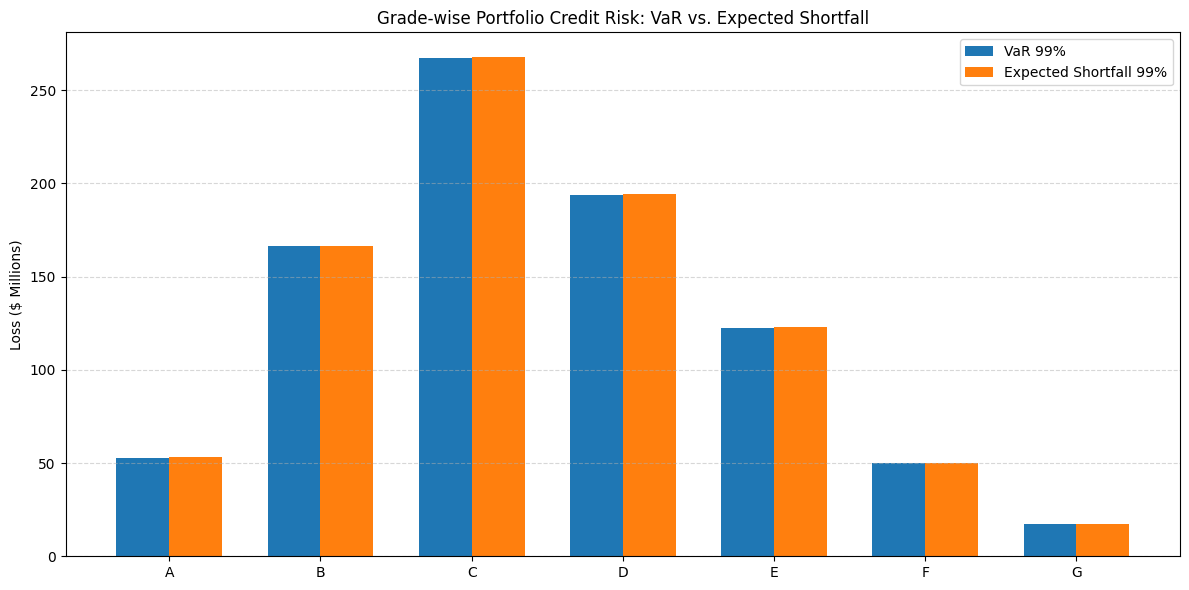

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare values
grade_risk_df = grade_risk_df[grade_risk_df['grade'] != '0']
grades = grade_risk_df['grade'].astype(str)
var_99 = grade_risk_df['VaR_99']  # Already float
es_99 = grade_risk_df['Expected_Shortfall_99']  # Already float

# Bar width and positions
bar_width = 0.35
x = np.arange(len(grades))

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, var_99 / 1e6, bar_width, label='VaR 99%')
plt.bar(x + bar_width/2, es_99 / 1e6, bar_width, label='Expected Shortfall 99%')

plt.xticks(x, grades)
plt.ylabel('Loss ($ Millions)')
plt.title('Grade-wise Portfolio Credit Risk: VaR vs. Expected Shortfall')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Risk Segmentation & Portfolio Loss Summary (Basel III/IV-Aligned)

Performed risk segmentation by **loan grade** (A–G) and estimated the **distribution of portfolio losses** using **Monte Carlo simulations** (10,000 iterations). Each simulation draws default outcomes based on predicted PDs and computes total loss as:

$$
\text{Loss}_i = \text{Default}_{i,s} \times \text{LGD} \times \text{EAD}_i
$$



#### **Key Outputs**
- **Value at Risk (VaR 99%)**: The **maximum expected loss** at 99% confidence.
- **Expected Shortfall (ES 99%)**: The **average loss beyond** the 99% VaR threshold.
- **Average Loss**: Mean simulated loss across all scenarios.



#### **Basel III/IV Alignment**
Under Basel’s Internal Ratings-Based (IRB) approach:
- **VaR and ES** are core components for modeling **unexpected loss (UL)**.
- **LGD**, **EAD**, and **PD** are estimated or stressed under downturn conditions.
- Segmenting by credit grade aligns with **risk-weighted capital** assignment.

